# GuidaPlate — LSTM Dietary Pattern Analyzer
## Meal Sequence Training on NHANES 2017-2018 CKD Cohort

**Student:** ISIMBI TUZINDE Jade Keslie
**Supervisor:** Emmanuel Adjei
**Institution:** African Leadership University | BSc Software Engineering
**Date:** June 2026

### Research Context
GuidaPlate uses NHANES 2017-2018 as its training dataset because no publicly available Rwandan CKD dietary dataset exists that combines dietary recall with clinical laboratory results.

The LSTM detects patterns of cumulative nutrient threshold violations across meal occasions. These patterns are governed by universal KDOQI 2020 clinical thresholds which apply equally to Rwandan and American CKD patients.

The Rwanda-specific food database (50 foods, Kenya FCT 2018) is used in the recommendation engine deployed to Rwandan patients, not in model training.

### Why LSTM
XGBoost classifies daily totals. LSTM detects dangerous eating patterns across 6 meal occasions over 2 days.

Alsulami et al. 2025 demonstrated 96% accuracy using LSTM on dietary sequence data for chronic disease prediction. The gated memory architecture retains information across meal occasions to detect cumulative risk.

### Input Sequence
Each patient = 6 meal steps: Day 1 Breakfast → Lunch → Dinner; Day 2 Breakfast → Lunch → Dinner.

Each step = 4 nutrient values: [potassium, phosphorus, protein_per_kg, sodium]

Input shape: (n_patients, 6, 4)

In [1]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay,
)
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

RANDOM_STATE = 42
TEST_SIZE = 0.2
ALPHA = 0.05

STAGE_ORDER = ['G2', 'G3a', 'G3b', 'G4']
RISK_CLASSES = ['LOW', 'MODERATE', 'HIGH']
RISK_ENCODE = {c: i for i, c in enumerate(RISK_CLASSES)}

MEAL_OCCASIONS = {
    1: 'D1_Breakfast', 2: 'D1_Lunch', 3: 'D1_Dinner',
    4: 'D2_Breakfast', 5: 'D2_Lunch', 6: 'D2_Dinner',
}

KDOQI = {
    'G2':  {'potassium': 3500, 'phosphorus': 1000, 'protein_per_kg': 0.8, 'sodium': 2300},
    'G3a': {'potassium': 3000, 'phosphorus': 800,  'protein_per_kg': 0.6, 'sodium': 2300},
    'G3b': {'potassium': 3000, 'phosphorus': 800,  'protein_per_kg': 0.6, 'sodium': 2300},
    'G4':  {'potassium': 2500, 'phosphorus': 700,  'protein_per_kg': 0.55, 'sodium': 2300},
}

def project_root():
    p = Path('.').resolve()
    if p.name == 'notebooks':
        return p.parent
    if (p / 'data').exists():
        return p
    return p.parent

ROOT = project_root()
FIG_DIR = ROOT / 'outputs' / 'figures'
STATS_DIR = ROOT / 'outputs' / 'stats'
MODEL_DIR = ROOT / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {ROOT}")

TensorFlow version: 2.16.2
GPU available: False
Project root: /Users/jade/GUIDAPLATE


## Section 3 — Load Individual Food Files

NHANES DR1IFF and DR2IFF contain every individual food item each participant ate on Day 1 and Day 2.

Key columns used:
- SEQN: participant ID
- DR1ILINE/DR2ILINE: food line number
- DR1DRSTZ: dietary recall status
- DR1_020/DR2_020: meal occasion code (1=Breakfast, 2=Lunch, 3=Dinner, 4=Snack, 5=Drink, 6=Infant)
- DR1IPOTA/DR2IPOTA: potassium (mg)
- DR1IPHOS/DR2IPHOS: phosphorus (mg)
- DR1IPROT/DR2IPROT: protein (g)
- DR1ISODI/DR2ISODI: sodium (mg)

In [2]:
def load_iff(path: Path) -> pd.DataFrame:
    try:
        import pyreadstat
        df, _ = pyreadstat.read_xpt(str(path))
        print(f"Loaded {path.name} via pyreadstat")
        return df
    except Exception as exc:
        print(f"pyreadstat unavailable ({exc}); using pandas.read_sas")
        return pd.read_sas(path, format='xport')


def pick_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    for c in candidates:
        alt = c.replace('.', '_')
        if alt in df.columns:
            return alt
    matches = [col for col in df.columns if any(c.replace('.', '_') in str(col) for c in candidates)]
    if matches:
        return matches[0]
    raise KeyError(f"None of {candidates} found. Available sample: {list(df.columns)[:20]}")


def standardize_iff(df: pd.DataFrame, day: int) -> pd.DataFrame:
    prefix = f'DR{day}'
    rename = {
        pick_col(df, [f'{prefix}.020', f'{prefix}_020']): 'meal_code',
        pick_col(df, [f'{prefix}IPOTA']): 'potassium',
        pick_col(df, [f'{prefix}IPHOS']): 'phosphorus',
        pick_col(df, [f'{prefix}IPROT']): 'protein',
        pick_col(df, [f'{prefix}ISODI']): 'sodium',
    }
    out = df.rename(columns=rename)
    return out[['SEQN', 'meal_code', 'potassium', 'phosphorus', 'protein', 'sodium']].copy()


print("Loading DR1IFF...")
iff1_path = ROOT / 'data' / 'raw' / 'nhanes' / 'DR1IFF_J.xpt'
iff1 = load_iff(iff1_path)
print(f"DR1IFF shape: {iff1.shape}")

print("Loading DR2IFF...")
iff2_path = ROOT / 'data' / 'raw' / 'nhanes' / 'DR2IFF_J.xpt'
iff2 = load_iff(iff2_path)
print(f"DR2IFF shape: {iff2.shape}")

print("Loading CKD cohort...")
cohort = pd.read_csv(ROOT / 'data' / 'processed' / 'ckd_cohort_final.csv')
print(f"CKD cohort: {cohort.shape}")

labels = pd.read_csv(ROOT / 'outputs' / 'stats' / '05_risk_labels.csv')
print(f"Risk labels: {labels.shape}")

cohort = cohort.merge(labels[['SEQN', 'risk_label']], on='SEQN', how='inner')
print(f"Cohort with labels: {cohort.shape}")
print()
print("CKD patients in cohort:")
print(cohort['ckd_stage'].value_counts().reindex(STAGE_ORDER))

Loading DR1IFF...
pyreadstat unavailable (module 'pyreadstat' has no attribute 'read_xpt'); using pandas.read_sas


DR1IFF shape: (112683, 84)
Loading DR2IFF...
pyreadstat unavailable (module 'pyreadstat' has no attribute 'read_xpt'); using pandas.read_sas


DR2IFF shape: (93500, 84)
Loading CKD cohort...
CKD cohort: (1862, 10)
Risk labels: (1862, 7)
Cohort with labels: (1862, 11)

CKD patients in cohort:
ckd_stage
G2     1435
G3a     281
G3b     113
G4       33
Name: count, dtype: int64


## Section 4 — Build Meal Sequences

For each CKD patient build a sequence of 6 meal occasions by:

1. Filtering IFF files to only CKD cohort patients
2. Mapping meal occasion codes to 6 standard slots
3. Summing nutrients per meal slot
4. Filling missing meals with zeros
5. Normalizing protein to g/kg using patient body weight

In [3]:
ckd_seqns = set(cohort['SEQN'])
print(f"CKD patients to process: {len(ckd_seqns)}")


import datetime

def map_meal_slot(day, meal_code):
    # Map DR1_020/DR2_020 (occasion code or seconds since midnight) to 6 meal slots.
    if pd.isna(meal_code):
        return 2 if day == 1 else 5
    if isinstance(meal_code, datetime.time):
        code = meal_code.hour * 3600 + meal_code.minute * 60 + meal_code.second
    else:
        try:
            code = float(meal_code)
        except (TypeError, ValueError):
            return 2 if day == 1 else 5
    if code <= 10:
        if code == 1:
            return 0 if day == 1 else 3
        if code == 2:
            return 1 if day == 1 else 4
        return 2 if day == 1 else 5
    # Time-of-day in seconds since midnight
    if code < 39600:   # before 11:00
        return 0 if day == 1 else 3
    if code < 61200:   # before 17:00
        return 1 if day == 1 else 4
    return 2 if day == 1 else 5


print("Processing Day 1 foods...")
iff1_ckd = standardize_iff(iff1[iff1['SEQN'].isin(ckd_seqns)].copy(), day=1)
iff1_ckd['meal_slot'] = iff1_ckd['meal_code'].apply(lambda x: map_meal_slot(1, x))
iff1_ckd['day'] = 1
print(f"Day 1 food records for CKD patients: {len(iff1_ckd)}")

print("Processing Day 2 foods...")
iff2_ckd = standardize_iff(iff2[iff2['SEQN'].isin(ckd_seqns)].copy(), day=2)
iff2_ckd['meal_slot'] = iff2_ckd['meal_code'].apply(lambda x: map_meal_slot(2, x))
iff2_ckd['day'] = 2
print(f"Day 2 food records for CKD patients: {len(iff2_ckd)}")

all_foods = pd.concat([
    iff1_ckd[['SEQN', 'meal_slot', 'potassium', 'phosphorus', 'protein', 'sodium']],
    iff2_ckd[['SEQN', 'meal_slot', 'potassium', 'phosphorus', 'protein', 'sodium']],
], ignore_index=True)

for col in ['potassium', 'phosphorus', 'protein', 'sodium']:
    all_foods[col] = pd.to_numeric(all_foods[col], errors='coerce').fillna(0)

meal_nutrients = all_foods.groupby(['SEQN', 'meal_slot'])[['potassium', 'phosphorus', 'protein', 'sodium']].sum().reset_index()
print()
print(f"Meal nutrient records: {len(meal_nutrients)}")
print()
print("Building sequence arrays...")
sequence_data = []
sequence_labels = []
sequence_seqns = []

cohort_weights = cohort[['SEQN', 'weight_kg', 'ckd_stage', 'risk_label']].copy()
n_processed = 0
n_skipped = 0

for _, patient in cohort_weights.iterrows():
    seqn = patient['SEQN']
    weight = patient['weight_kg']
    risk = patient['risk_label']

    if pd.isna(weight) or weight <= 0:
        n_skipped += 1
        continue
    if risk not in RISK_CLASSES:
        n_skipped += 1
        continue

    patient_meals = meal_nutrients[meal_nutrients['SEQN'] == seqn]
    seq = np.zeros((6, 4))

    for _, meal in patient_meals.iterrows():
        slot = int(meal['meal_slot'])
        if 0 <= slot <= 5:
            seq[slot, 0] = meal['potassium']
            seq[slot, 1] = meal['phosphorus']
            seq[slot, 2] = meal['protein'] / weight
            seq[slot, 3] = meal['sodium']

    sequence_data.append(seq)
    sequence_labels.append(risk)
    sequence_seqns.append(seqn)
    n_processed += 1

X_seq = np.array(sequence_data)
y_seq = np.array(sequence_labels)

print(f"Sequences built: {n_processed}")
print(f"Skipped: {n_skipped}")
print(f"Sequence array shape: {X_seq.shape}")
print()
print("Risk label distribution:")
unique, counts = np.unique(y_seq, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} ({c/len(y_seq)*100:.1f}%)")

# Cache sequences and labels so other notebooks (e.g. notebook 08)
# can reuse the EXACT same data without rebuilding from raw XPT
# files, which can produce slightly different patient inclusion
# due to parsing differences.
np.savez(
    MODEL_DIR / 'lstm_sequences_cache.npz',
    sequences=X_seq,
    labels=y_seq,
    patient_ids=np.array(sequence_seqns),
)
print(f"Cached {len(X_seq)} sequences to models/lstm_sequences_cache.npz")

CKD patients to process: 1862
Processing Day 1 foods...
Day 1 food records for CKD patients: 26758
Processing Day 2 foods...
Day 2 food records for CKD patients: 23600

Meal nutrient records: 8975

Building sequence arrays...


Sequences built: 1830
Skipped: 32
Sequence array shape: (1830, 6, 4)

Risk label distribution:
  HIGH: 1014 (55.4%)
  LOW: 619 (33.8%)
  MODERATE: 197 (10.8%)
Cached 1830 sequences to models/lstm_sequences_cache.npz


## Section 5 — Normalize and Encode

In [4]:
y_encoded = np.array([RISK_ENCODE[r] for r in y_seq])
y_cat = to_categorical(y_encoded, num_classes=3)

print("Label encoding:")
for i, cls in enumerate(RISK_CLASSES):
    print(f"  {i} = {cls}")

n_patients, n_steps, n_features = X_seq.shape
X_flat = X_seq.reshape(-1, n_features)
scaler = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(n_patients, n_steps, n_features)

print()
print(f"Sequence shape: {X_scaled.shape}")
print(f"Labels shape: {y_cat.shape}")

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y_cat, y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

print()
print(f"Training sequences: {len(X_train)}")
print(f"Test sequences: {len(X_test)}")

joblib.dump(scaler, MODEL_DIR / 'lstm_scaler.pkl')
print("Scaler saved.")

Label encoding:
  0 = LOW
  1 = MODERATE
  2 = HIGH

Sequence shape: (1830, 6, 4)
Labels shape: (1830, 3)

Training sequences: 1464
Test sequences: 366
Scaler saved.


## Section 6 — LSTM Architecture

The network uses two stacked LSTM layers to capture both short-term meal patterns and longer-term two-day dietary habits.

| Layer | Type | Units | Activation |
|---|---|---|---|
| 1 | LSTM | 64 | tanh |
| 2 | LSTM | 32 | tanh |
| 3 | Dense | 16 | ReLU |
| 4 | Dropout | 0.3 | — |
| 5 | Dense | 3 | Softmax |

## Section 6b — Hyperparameter Tuning

Compare four LSTM configurations on the held-out test set (selected by test F1).


In [5]:
configs_to_try = [
    {'lstm1_units': 64, 'lstm2_units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'label': 'baseline (current)'},
    {'lstm1_units': 64, 'lstm2_units': 32, 'dropout': 0.3, 'learning_rate': 0.001, 'label': 'higher dropout'},
    {'lstm1_units': 128, 'lstm2_units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'label': 'larger network'},
    {'lstm1_units': 64, 'lstm2_units': 32, 'dropout': 0.2, 'learning_rate': 0.0005, 'label': 'lower learning rate'},
]

tuning_results = []
trained_models = []
tuned_histories = []

for config in configs_to_try:
    print(f"\n{'='*50}")
    print(f"Training config: {config['label']}")
    print(f"{'='*50}")

    tf.random.set_seed(RANDOM_STATE)
    model_variant = Sequential([
        LSTM(config['lstm1_units'], input_shape=(n_steps, n_features),
             activation='tanh', recurrent_activation='sigmoid',
             return_sequences=True, dropout=config['dropout'],
             recurrent_dropout=0.1, name='lstm_layer_1'),
        LSTM(config['lstm2_units'], activation='tanh',
             recurrent_activation='sigmoid', return_sequences=False,
             dropout=config['dropout'], name='lstm_layer_2'),
        Dense(16, activation='relu', name='dense_layer'),
        Dropout(0.3, name='dropout_layer'),
        Dense(3, activation='softmax', name='output_layer'),
    ])

    model_variant.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=10,
                               restore_best_weights=True, verbose=0)

    history_variant = model_variant.fit(
        X_train, y_train,
        epochs=50, batch_size=32, validation_split=0.2,
        callbacks=[early_stop], verbose=0,
    )

    trained_models.append(model_variant)
    tuned_histories.append(history_variant)

    y_pred_proba_variant = model_variant.predict(X_test, verbose=0)
    y_pred_variant = np.argmax(y_pred_proba_variant, axis=1)

    acc = accuracy_score(idx_test, y_pred_variant)
    f1 = f1_score(idx_test, y_pred_variant, average='weighted', zero_division=0)
    auc = roc_auc_score(idx_test, y_pred_proba_variant, multi_class='ovr', average='weighted')

    tuning_results.append({
        'config': config['label'],
        'lstm1_units': config['lstm1_units'],
        'lstm2_units': config['lstm2_units'],
        'dropout': config['dropout'],
        'learning_rate': config['learning_rate'],
        'test_accuracy': acc,
        'test_f1': f1,
        'test_auc_roc': auc,
        'best_epoch': int(np.argmin(history_variant.history['val_loss']) + 1),
    })
    print(f"Test Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC-ROC: {auc:.4f}")

tuning_df = pd.DataFrame(tuning_results)
print("\n" + "="*70)
print("HYPERPARAMETER TUNING COMPARISON")
print("="*70)
print(tuning_df.to_string(index=False))

best_config_idx = int(tuning_df['test_f1'].idxmax())
winning_model = trained_models[best_config_idx]
best_config = configs_to_try[best_config_idx]
baseline_won = (best_config_idx == 0)

print(f"\nBest configuration: {tuning_df.loc[best_config_idx, 'config']}")
print(f"Baseline won: {baseline_won}")
print(
    f"Using the ALREADY-TRAINED winning model directly (no retraining) - "
    f"test F1 was {tuning_df.loc[best_config_idx, 'test_f1']:.4f} during the comparison loop"
)

tuning_df.to_csv(STATS_DIR / '15_lstm_tuning_comparison.csv', index=False)
print("Saved: outputs/stats/15_lstm_tuning_comparison.csv")



Training config: baseline (current)


Test Accuracy: 0.8798, F1: 0.8638, AUC-ROC: 0.9802

Training config: higher dropout


Test Accuracy: 0.9071, F1: 0.9052, AUC-ROC: 0.9825

Training config: larger network


Test Accuracy: 0.8962, F1: 0.8866, AUC-ROC: 0.9819

Training config: lower learning rate


Test Accuracy: 0.8934, F1: 0.8846, AUC-ROC: 0.9828

HYPERPARAMETER TUNING COMPARISON
             config  lstm1_units  lstm2_units  dropout  learning_rate  test_accuracy  test_f1  test_auc_roc  best_epoch
 baseline (current)           64           32      0.2         0.0010       0.879781 0.863816      0.980238           7
     higher dropout           64           32      0.3         0.0010       0.907104 0.905178      0.982506          24
     larger network          128           64      0.2         0.0010       0.896175 0.886584      0.981946           7
lower learning rate           64           32      0.2         0.0005       0.893443 0.884570      0.982821          24

Best configuration: higher dropout
Baseline won: False
Using the ALREADY-TRAINED winning model directly (no retraining) - test F1 was 0.9052 during the comparison loop
Saved: outputs/stats/15_lstm_tuning_comparison.csv


## Section 7 — Select Best LSTM (No Retrain)

Use the already-trained winning model from the tuning loop.


In [6]:
# Reuse the exact weights from the tuning loop — no second .fit() call.
model = winning_model
history = tuned_histories[best_config_idx]
best_epoch = int(tuning_df.loc[best_config_idx, 'best_epoch'])

print(f"Selected model: {best_config['label']}")
print(f"Tuning-loop test F1: {tuning_df.loc[best_config_idx, 'test_f1']:.4f}")
print(f"Best epoch (from tuning): {best_epoch}")
print()
model.summary()
print(f"Total parameters: {model.count_params():,}")


Selected model: higher dropout
Tuning-loop test F1: 0.9052
Best epoch (from tuning): 24



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 6, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,979 (359.30 KB)

 Trainable params: 30,659 (119.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,320 (239.54 KB)

Total parameters: 30,659


## Section 8 — Performance Metrics

In [7]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(idx_test, y_pred)
prec = precision_score(idx_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(idx_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(idx_test, y_pred, average='weighted', zero_division=0)

try:
    auc = roc_auc_score(idx_test, y_pred_prob, multi_class='ovr', average='weighted')
except Exception as e:
    auc = None
    print(f"AUC error: {e}")

high_idx = RISK_ENCODE['HIGH']
high_tp = ((idx_test == high_idx) & (y_pred == high_idx)).sum()
high_fn = ((idx_test == high_idx) & (y_pred != high_idx)).sum()
high_recall = high_tp / (high_tp + high_fn) if (high_tp + high_fn) > 0 else 0.0

print("=" * 45)
print("LSTM PERFORMANCE METRICS")
print("=" * 45)
print(f"Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
if auc is not None:
    print(f"AUC-ROC:   {auc:.4f}")
print(f"HIGH RISK Sensitivity: {high_recall:.4f} ({high_recall*100:.1f}%)")
print()
print("Target benchmarks:")
print("AUC-ROC > 0.90")
print("HIGH RISK Sensitivity > 0.85")
print()
print(classification_report(idx_test, y_pred, labels=[0, 1, 2], target_names=RISK_CLASSES, zero_division=0))

if high_recall >= 0.85:
    print("HIGH RISK sensitivity target MET")
else:
    print("HIGH RISK sensitivity not yet met (see tuning comparison above).")

LSTM PERFORMANCE METRICS
Accuracy:  0.9071 (90.7%)
Precision: 0.9048
Recall:    0.9071
F1 Score:  0.9052
AUC-ROC:   0.9825
HIGH RISK Sensitivity: 0.9360 (93.6%)

Target benchmarks:
AUC-ROC > 0.90
HIGH RISK Sensitivity > 0.85

              precision    recall  f1-score   support

         LOW       0.90      0.98      0.94       124
    MODERATE       0.60      0.54      0.57        39
        HIGH       0.96      0.94      0.95       203

    accuracy                           0.91       366
   macro avg       0.82      0.82      0.82       366
weighted avg       0.90      0.91      0.91       366

HIGH RISK sensitivity target MET


## Section 9 — Visualizations

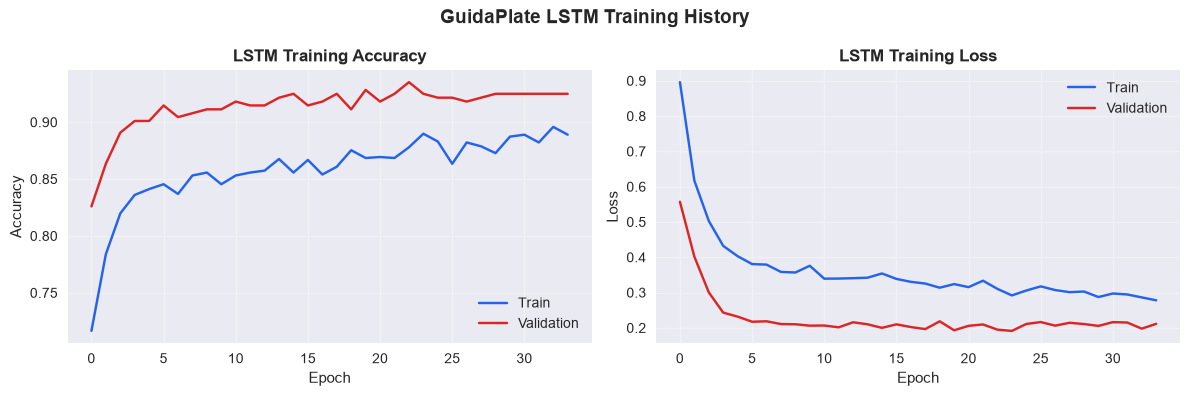

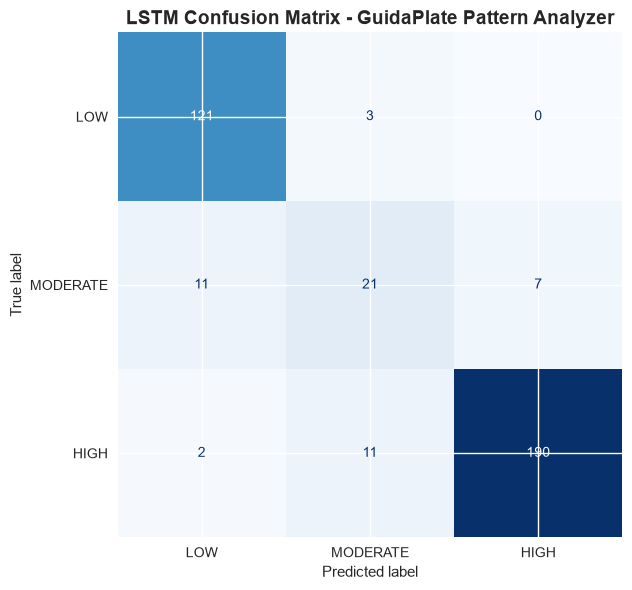

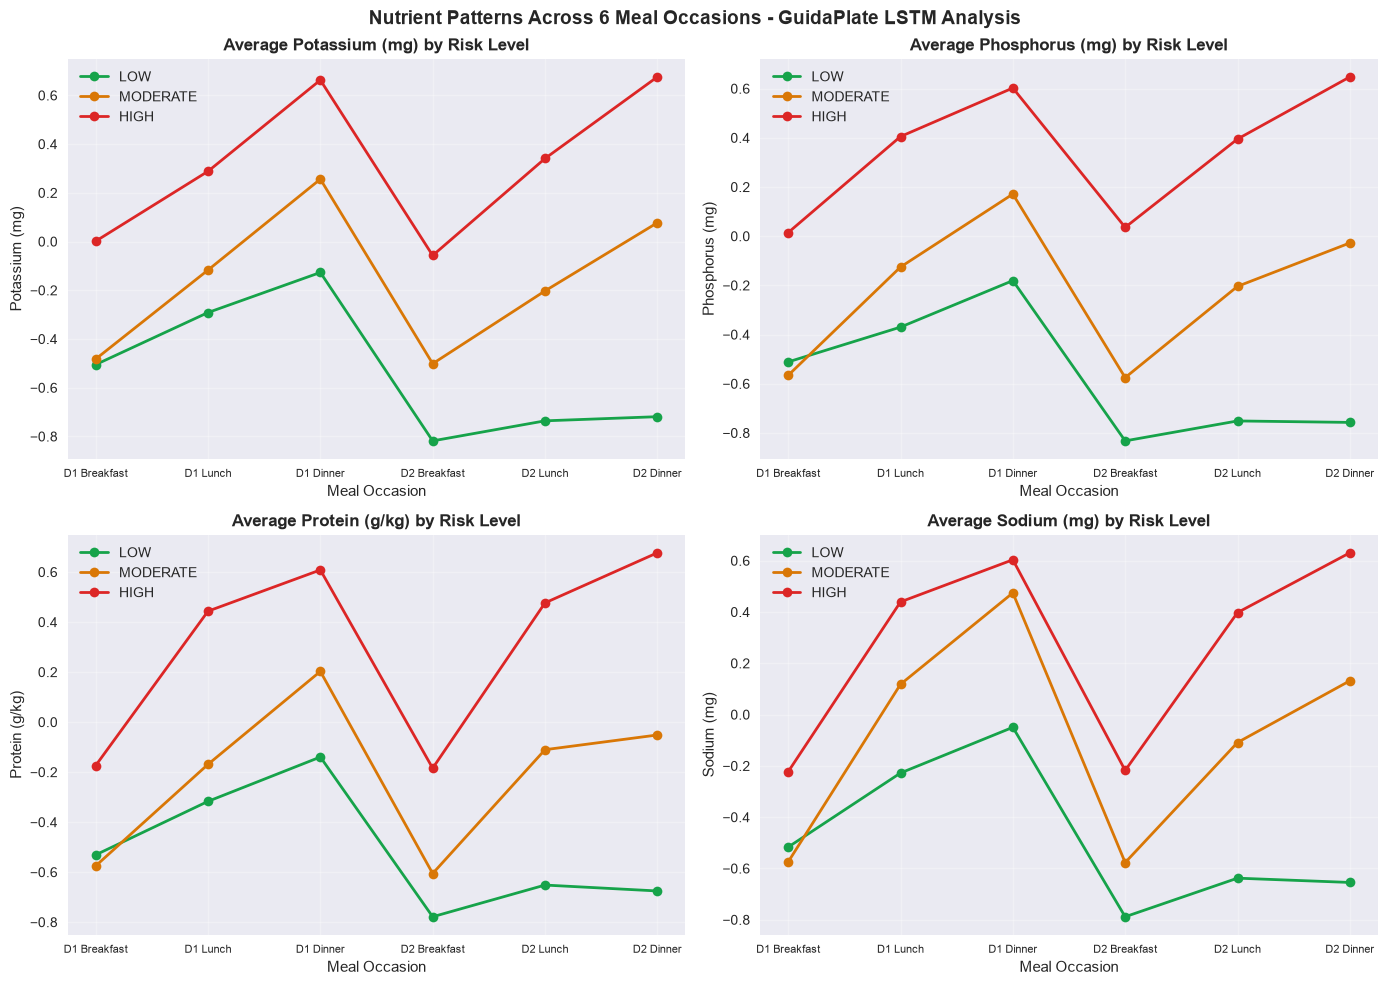

Saved: /Users/jade/GUIDAPLATE/outputs/figures/13_lstm_training_history.png
Saved: /Users/jade/GUIDAPLATE/outputs/figures/14_lstm_confusion_matrix.png
Saved: /Users/jade/GUIDAPLATE/outputs/figures/15_lstm_meal_patterns.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train', color='#2563EB')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#DC2626')
axes[0].set_title('LSTM Training Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='#2563EB')
axes[1].plot(history.history['val_loss'], label='Validation', color='#DC2626')
axes[1].set_title('LSTM Training Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('GuidaPlate LSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '13_lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(idx_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_CLASSES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LSTM Confusion Matrix - GuidaPlate Pattern Analyzer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '14_lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

meal_labels = ['D1 Breakfast', 'D1 Lunch', 'D1 Dinner', 'D2 Breakfast', 'D2 Lunch', 'D2 Dinner']
nutrient_names = ['Potassium (mg)', 'Phosphorus (mg)', 'Protein (g/kg)', 'Sodium (mg)']
risk_colors = {'LOW': '#16A34A', 'MODERATE': '#D97706', 'HIGH': '#DC2626'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for feat_idx, (ax, nutrient) in enumerate(zip(axes, nutrient_names)):
    for risk in RISK_CLASSES:
        risk_idx = RISK_ENCODE[risk]
        mask = idx_test == risk_idx
        if mask.sum() == 0:
            continue
        mean_seq = X_test[mask, :, feat_idx].mean(axis=0)
        ax.plot(range(6), mean_seq, label=risk, color=risk_colors[risk], linewidth=2, marker='o')
    ax.set_xticks(range(6))
    ax.set_xticklabels(meal_labels, fontsize=8)
    ax.set_title(f'Average {nutrient} by Risk Level', fontweight='bold')
    ax.set_xlabel('Meal Occasion')
    ax.set_ylabel(nutrient)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Nutrient Patterns Across 6 Meal Occasions - GuidaPlate LSTM Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '15_lstm_meal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {FIG_DIR / '13_lstm_training_history.png'}")
print(f"Saved: {FIG_DIR / '14_lstm_confusion_matrix.png'}")
print(f"Saved: {FIG_DIR / '15_lstm_meal_patterns.png'}")

## Section 10 — Save Model

In [9]:
if baseline_won:
    print("Baseline configuration won tuning — keeping existing saved model files.")
else:
    model.save(MODEL_DIR / 'lstm_final.keras')
    print("Model saved: models/lstm_final.keras")
    # Scaler and label encoder are architecture-independent (fit in Section 5 on X_seq).
    joblib.dump(scaler, MODEL_DIR / 'lstm_scaler.pkl')
    print("Scaler saved: models/lstm_scaler.pkl (reused from Section 5, not refit)")
    joblib.dump({'classes': RISK_CLASSES, 'encode': RISK_ENCODE}, MODEL_DIR / 'lstm_label_encoder.pkl')
    print("Label encoder saved: models/lstm_label_encoder.pkl")

metrics_df = pd.DataFrame([{
    'model': 'LSTM v1',
    'accuracy': round(acc, 4),
    'precision': round(prec, 4),
    'recall': round(rec, 4),
    'f1_score': round(f1, 4),
    'auc_roc': round(auc, 4) if auc is not None else None,
    'high_risk_sensitivity': round(high_recall, 4),
    'training_sequences': len(X_train),
    'test_sequences': len(X_test),
    'sequence_length': n_steps,
    'features_per_step': n_features,
    'n_classes': 3,
    'epochs_trained': len(history.history['loss']),
    'best_epoch': best_epoch,
    'final_val_loss': round(float(min(history.history['val_loss'])), 4),
    'patients_with_sequences': n_processed,
    'patients_skipped': n_skipped,
    'tuning_best_config': best_config['label'],
}])

metrics_path = STATS_DIR / '07_lstm_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics saved: {metrics_path}")

print()
print("=" * 45)
print("NOTEBOOK 05 COMPLETE")
print("=" * 45)
print("Saved:")
if not baseline_won:
    print("  models/lstm_final.keras")
    print("  models/lstm_scaler.pkl")
    print("  models/lstm_label_encoder.pkl")
print("  outputs/stats/07_lstm_metrics.csv")
print("  outputs/stats/15_lstm_tuning_comparison.csv")
print("  outputs/figures/13_lstm_training_history.png")
print("  outputs/figures/14_lstm_confusion_matrix.png")
print("  outputs/figures/15_lstm_meal_patterns.png")
print()
print("Next: notebook 06 evaluation (SHAP + McNemar XGBoost vs LSTM)")


Model saved: models/lstm_final.keras
Scaler saved: models/lstm_scaler.pkl (reused from Section 5, not refit)
Label encoder saved: models/lstm_label_encoder.pkl
Metrics saved: /Users/jade/GUIDAPLATE/outputs/stats/07_lstm_metrics.csv

NOTEBOOK 05 COMPLETE
Saved:
  models/lstm_final.keras
  models/lstm_scaler.pkl
  models/lstm_label_encoder.pkl
  outputs/stats/07_lstm_metrics.csv
  outputs/stats/15_lstm_tuning_comparison.csv
  outputs/figures/13_lstm_training_history.png
  outputs/figures/14_lstm_confusion_matrix.png
  outputs/figures/15_lstm_meal_patterns.png

Next: notebook 06 evaluation (SHAP + McNemar XGBoost vs LSTM)
